In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
import os
import json
import pandas as pd

# 1) Discover & sort shrink_train directories
dirs = sorted(
    [d for d in os.listdir('.') 
     if os.path.isdir(d) and d.startswith('shrink_train_')],
    # extract the number after the second underscore
    key=lambda x: int(x.split('_')[2])
)

# 2) Collect metrics into a list of dicts
records = []
for d in dirs:
    metrics_path = os.path.join(d, 'performance_metrics.json')
    if not os.path.exists(metrics_path):
        print(f"Warning: no metrics in {d}, skipping")
        continue

    with open(metrics_path, 'r') as f:
        metrics = json.load(f)

    # parse out N
    N = int(d.split('_')[2])
    rec = {'N_removed': N}

    # flatten output_1 and output_2 metrics
    for output in ['output_1', 'output_2']:
        for m in ['r2', 'mae', 'mape', 'rmse', 'rmspe']:
            rec[f"{output}_{m}"] = metrics.get(output, {}).get(m, None)

    records.append(rec)

# 3) Build and sort DataFrame
df = pd.DataFrame(records)
df = df.sort_values('N_removed').reset_index(drop=True)
df['N_sensors'] = df['N_removed'].iloc[::-1].values
df

,N_removed,output_1_r2,output_1_mae,output_1_mape,output_1_rmse,output_1_rmspe,output_2_r2,output_2_mae,output_2_mape,output_2_rmse,output_2_rmspe,N_sensors
0,1,0.995113,9.697199,3.458915,12.923441,4.976784,0.982524,17.202501,12.960374,19.972521,15.187000,61
1,2,0.997788,7.143486,4.616601,8.695124,7.401309,0.990158,10.828763,10.868604,14.988434,17.344534,60
2,3,0.998438,4.804155,2.079573,7.306578,4.407791,0.994230,9.172298,14.048286,11.476123,22.626181,59
3,4,0.994139,11.833476,6.853224,14.153383,9.850765,0.995524,6.218498,6.074585,10.108067,12.012178,58
4,5,0.996699,6.725829,3.267807,10.621661,6.732960,0.993518,9.758479,12.296189,12.163539,19.503765,57
...,...,...,...,...,...,...,...,...,...,...,...,...
56,57,0.934862,25.953678,14.195681,47.183270,30.049387,0.818493,21.593168,7.720149,64.366806,14.644000,5
57,58,0.693568,49.301075,14.397925,102.337898,21.447356,0.388230,54.218044,17.101620,118.170425,24.824719,4
58,59,0.564595,74.119888,37.522161,121.987778,60.602200,-0.204523,93.831856,33.833101,165.814438,43.356040,3
59,60,0.362466,78.172829,25.744748,147.611923,40.073150,-0.338364,103.197060,39.034137,174.784134,48.358348,2


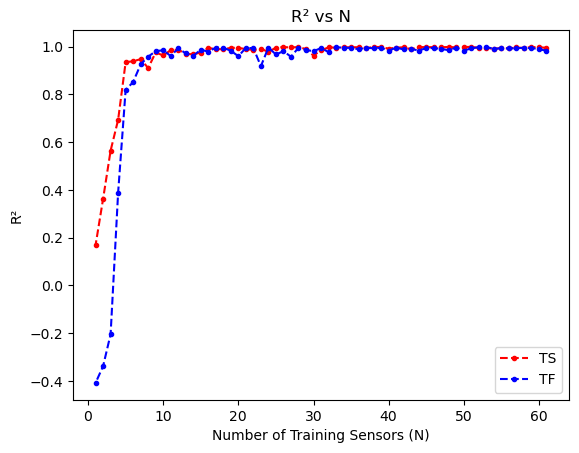

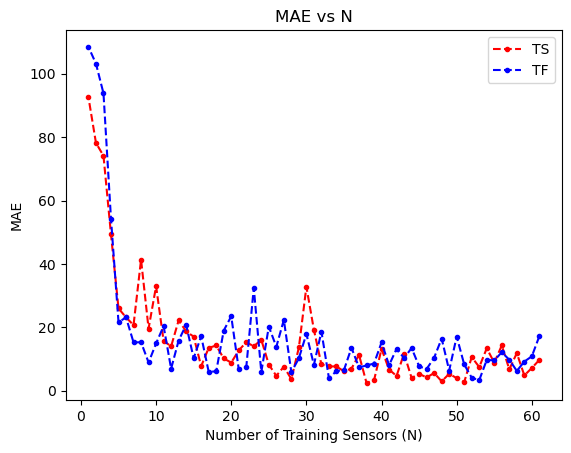

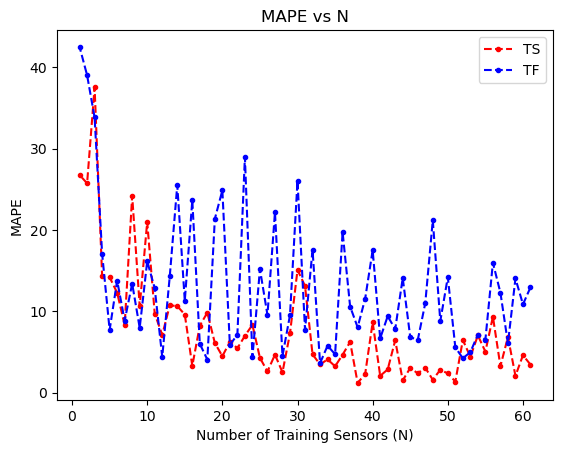

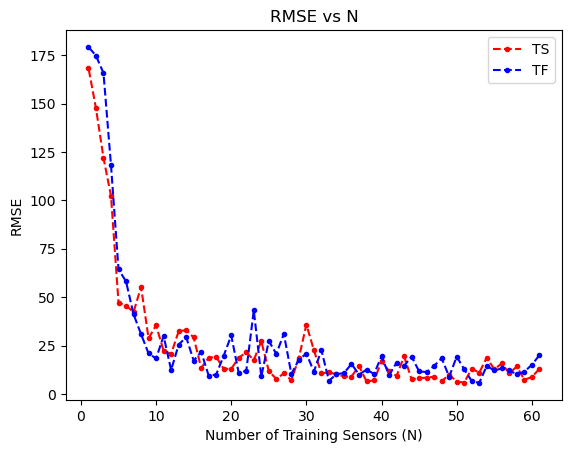

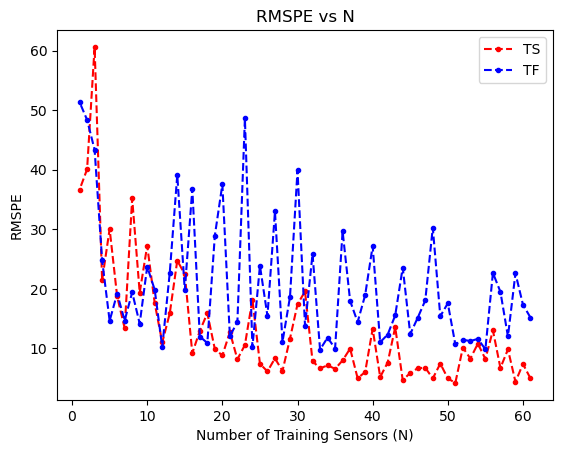

In [92]:
# Plot each metric vs. N
for metric in ['r2', 'mae', 'mape', 'rmse', 'rmspe']:
    plt.figure()
    plt.plot(df['N_sensors'], df[f'output_1_{metric}'], '--o', color='r',label='TS', markersize=3)
    plt.plot(df['N_sensors'], df[f'output_2_{metric}'], '--o', color='b',label='TF',  markersize=3)
    plt.xlabel('Number of Training Sensors (N)')
    ylabel = 'R\u00b2' if metric == 'r2' else metric.upper()
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs N")
    plt.legend()
    plt.show()

In [14]:
data = np.load('./shrink_train_1/Ypred.npy')
data.shape

(340060, 2, 3)

In [16]:
data = np.load('./shrink_train_1/Ytrue.npy')
data.shape

(340060, 2)

C:\Users\Logan\AppData\Local\Temp\ipykernel_28620\876771595.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm')
C:\Users\Logan\AppData\Local\Temp\ipykernel_28620\876771595.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


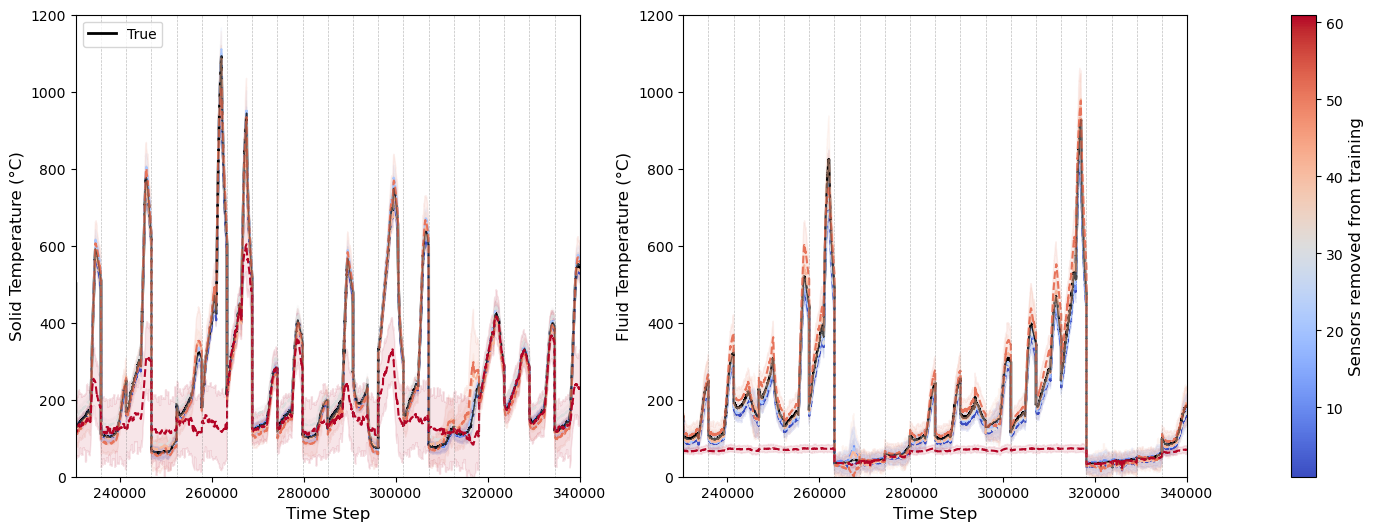

In [89]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# 1) Discover & sort shrink_train directories
dirs = sorted(
    [d for d in os.listdir('.') 
     if os.path.isdir(d) and d.startswith('shrink_train_')],
    key=lambda x: int(x.split('_')[2])
)

# 2) Load all runs (Ytrue: shape (T,2); Ypred: shape (T,2,3))
runs = []
for d in dirs:
    N = int(d.split('_')[2])
    tfile = os.path.join(d, 'Ytrue.npy')
    pfile = os.path.join(d, 'Ypred.npy')
    if os.path.exists(tfile) and os.path.exists(pfile):
        Ytrue = np.load(tfile)   # shape (T, 2)
        Ypred = np.load(pfile)   # shape (T, 2, 3)
        runs.append((N, Ytrue, Ypred))

# 3) Sample every 10th run (adjust interval as desired)
sampled = runs[::10]
if not sampled:
    raise RuntimeError("No valid runs found to plot.")

# Extract N-values to build a continuous norm
all_N = [entry[0] for entry in sampled]
minN, maxN = min(all_N), max(all_N)

# 4) Fixed x-axis endpoint (for alignment)
x_end = 340070

# 5) Build a continuous Normalize + ScalarMappable for the colorbar
norm = Normalize(vmin=minN, vmax=maxN)
cmap = cm.get_cmap('coolwarm')
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # for the colorbar

# 6) Create a single figure with a 1×3 GridSpec: [plot0 | colorbar | plot1]
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.3)

ax0  = fig.add_subplot(gs[0, 0])  # left panel for output 0
ax1  = fig.add_subplot(gs[0, 1])  # middle thin panel for colorbar
cax  = fig.add_subplot(gs[0, 2])  # right panel for output 1

for out_idx, ax in enumerate([ax0, ax1]):
    for i, (N, Ytrue, Ypred) in enumerate(sampled):
        length = Ypred.shape[0]    # T  (e.g. 340060)
        offset = x_end - length
        x_vals = np.arange(offset, offset + length)

        # 6a) Plot true series in black
        if i == 0:
            ax.plot(
                x_vals,
                Ytrue[:, out_idx],
                color='black',
                linewidth=2,
                label='True'
            )
        else:
            ax.plot(
                x_vals,
                Ytrue[:, out_idx],
                color='black',
                linewidth=1,
                alpha=0.3
            )

        # 6b) Extract mean, lower_ci, upper_ci
        mean_pred = Ypred[:, out_idx, 0]
        lower_ci  = Ypred[:, out_idx, 1]
        upper_ci  = Ypred[:, out_idx, 2]

        # 6c) Compute line color from N
        color = sm.to_rgba(N)

        # 6d) Plot predicted mean (dashed)
        ax.plot(
            x_vals,
            mean_pred,
            linestyle='--',
            color=color,
            alpha=1.0
        )

        # 6e) Shade the CI band
        ax.fill_between(
            x_vals,
            lower_ci,
            upper_ci,
            color=color,
            alpha=0.1
        )

    # 7) Axis labels, title, limits
    ylabel = 'TS' if out_idx == 0 else 'TF'
    ax.set_xlabel('Time Step', fontsize=12)
    #x.set_title(f"{ylabel} — True vs Predicted (95% CI)", fontsize=14)
    if out_idx == 0:
        ax.set_ylabel('Solid Temperature (°C)', fontsize=12)
    else:
        ax.set_ylabel('Fluid Temperature (°C)', fontsize=12)
    ax.set_xlim(x_end - 20 * 5485, x_end)
    ax.set_ylim(0, 1200)

    # 8) Vertical sensor boundaries every 5485 steps
    for x_val in np.arange(5485, x_end, 5485):
        ax.vlines(
            x=x_val,
            ymin=-100, ymax=1500,
            color='gray',
            linestyle='--',
            linewidth=0.5,
            alpha=0.5
        )

    # 9) Only add a legend for “True” once (on the left panel)
    if out_idx == 0:
        ax.legend(loc='upper left')

# 10) Place the colorbar in the middle thin column
cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation='vertical'
)
cbar.set_label('Sensors removed from training', fontsize=12)

plt.tight_layout()
fig.savefig('HTTF_remove_sensors_preds.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Logan\AppData\Local\Temp\ipykernel_28620\2715821868.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\Logan\AppData\Local\Temp\ipykernel_28620\2715821868.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


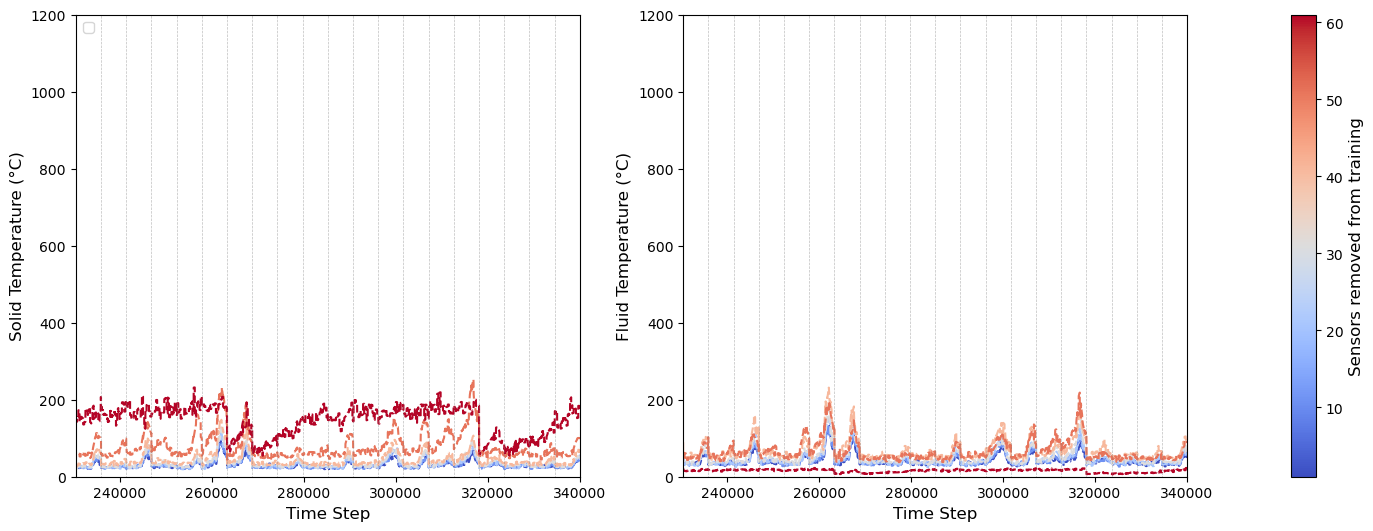

In [86]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# 1) Discover & sort shrink_train directories
dirs = sorted(
    [d for d in os.listdir('.') 
     if os.path.isdir(d) and d.startswith('shrink_train_')],
    key=lambda x: int(x.split('_')[2])
)

# 2) Load all runs (Ytrue: shape (T,2); Ypred: shape (T,2,3))
runs = []
for d in dirs:
    N = int(d.split('_')[2])
    tfile = os.path.join(d, 'Ytrue.npy')
    pfile = os.path.join(d, 'Ypred.npy')
    if os.path.exists(tfile) and os.path.exists(pfile):
        Ytrue = np.load(tfile)   # shape (T, 2)
        Ypred = np.load(pfile)   # shape (T, 2, 3)
        runs.append((N, Ytrue, Ypred))

# 3) Sample every 10th run (adjust interval as desired)
sampled = runs[::10]
if not sampled:
    raise RuntimeError("No valid runs found to plot.")

# Extract N-values to build a continuous norm
all_N = [entry[0] for entry in sampled]
minN, maxN = min(all_N), max(all_N)

# 4) Fixed x-axis endpoint (for alignment)
x_end = 340070

# 5) Build a continuous Normalize + ScalarMappable for the colorbar
norm = Normalize(vmin=minN, vmax=maxN)
cmap = cm.get_cmap('coolwarm')
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # for the colorbar

# 6) Create a single figure with a 1×3 GridSpec: [plot0 | colorbar | plot1]
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.3)

ax0  = fig.add_subplot(gs[0, 0])  # left panel for output 0
ax1  = fig.add_subplot(gs[0, 1])  # middle thin panel for colorbar
cax  = fig.add_subplot(gs[0, 2])  # right panel for output 1

for out_idx, ax in enumerate([ax0, ax1]):
    for i, (N, Ytrue, Ypred) in enumerate(sampled):
        length = Ypred.shape[0]    # T  (e.g. 340060)
        offset = x_end - length
        x_vals = np.arange(offset, offset + length)

        # 6a) Plot true series in black
        # if i == 0:
        #     ax.plot(
        #         x_vals,
        #         Ytrue[:, out_idx],
        #         color='black',
        #         linewidth=2,
        #         label='True'
        #     )
        # else:
        #     ax.plot(
        #         x_vals,
        #         Ytrue[:, out_idx],
        #         color='black',
        #         linewidth=1,
        #         alpha=0.3
        #     )

        # 6b) Extract mean, lower_ci, upper_ci
        mean_pred = Ypred[:, out_idx, 0]
        lower_ci  = Ypred[:, out_idx, 1]
        upper_ci  = Ypred[:, out_idx, 2]

        # 6c) Compute line color from N
        color = sm.to_rgba(N)

        # 6d) Plot predicted mean (dashed)
        ax.plot(
            x_vals,
            upper_ci-lower_ci,
            linestyle='--',
            color=color,
            alpha=1.0
        )

        # 6e) Shade the CI band
        # ax.fill_between(
        #     x_vals,
        #     lower_ci,
        #     upper_ci,
        #     color=color,
        #     alpha=0.1
        # )

    # 7) Axis labels, title, limits
    ylabel = 'TS' if out_idx == 0 else 'TF'
    ax.set_xlabel('Time Step', fontsize=12)
    #x.set_title(f"{ylabel} — True vs Predicted (95% CI)", fontsize=14)
    if out_idx == 0:
        ax.set_ylabel('Solid Temperature (°C)', fontsize=12)
    else:
        ax.set_ylabel('Fluid Temperature (°C)', fontsize=12)
    ax.set_xlim(x_end - 20 * 5485, x_end)
    ax.set_ylim(0, 1200)

    # 8) Vertical sensor boundaries every 5485 steps
    for x_val in np.arange(5485, x_end, 5485):
        ax.vlines(
            x=x_val,
            ymin=-100, ymax=1500,
            color='gray',
            linestyle='--',
            linewidth=0.5,
            alpha=0.5
        )

    # 9) Only add a legend for “True” once (on the left panel)
    if out_idx == 0:
        ax.legend(loc='upper left')

# 10) Place the colorbar in the middle thin column
cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation='vertical'
)
cbar.set_label('Sensors removed from training', fontsize=12)

plt.tight_layout()
plt.show()